# Capstone: Predicting Titanic survival

**Question:** Can information known about a passenger before the voyage help us predict survival?

This notebook demonstrates a complete binary-classification workflow: validate the data contract, lock away a test set, explore training data, compare leakage-safe pipelines with cross-validation, interpret a model on a training-derived validation set, and report one final test result.

**Primary metric:** ROC AUC, because it evaluates ranking across decision thresholds. Accuracy and class-specific recall are secondary diagnostics.

**Reproducibility:** all randomized steps use explicit seeds. Run the notebook from top to bottom.

## 1. Setup

We keep imports and display settings together. The warning filter only hides a harmless seaborn/pandas deprecation warning; model warnings remain visible.

In [1]:
import hashlib
import ssl
import warnings
from pathlib import Path
from urllib.error import URLError

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")
RANDOM_STATE = 42
INTERPRETATION_RANDOM_STATE = 43
BOOTSTRAP_RANDOM_STATE = 2026
TEST_SIZE = 0.20
VALIDATION_SIZE = 0.20
PRIMARY_METRIC = "ROC AUC"
PRIMARY_SCORING = "roc_auc"
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

print("Split seed:", RANDOM_STATE)
print("Primary metric:", PRIMARY_METRIC)

Split seed: 42
Primary metric: ROC AUC


## 2. Load, validate, and immediately lock the test set

The preferred source is seaborn's public `master`-branch CSV. Because networks and SSL can fail, loading falls back to the checked local snapshot in `datasets/titanic.csv`; its SHA-256 digest is verified before use. The notebook prints the source it actually loaded. `master` remains mutable, so the explicit contract checks below deliberately stop execution if the remote schema changes.

Only schema checks touch the complete file. Immediately afterward, a stratified test set is locked away. Every target-related table and EDA plot later in the notebook uses training data only.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
LOCAL_DATA_CANDIDATES = [Path("../datasets/titanic.csv"), Path("datasets/titanic.csv")]
LOCAL_SNAPSHOT_SHA256 = "81787d320d7f7b03df935e91de8bd19e11d45c5bbcab86ef4d4a76dc91b7d4f2"
EXPECTED_COLUMNS = [
    "survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked",
    "class", "who", "adult_male", "deck", "embark_town", "alive", "alone",
]

try:
    df = pd.read_csv(DATA_URL)
    data_source = f"remote URL: {DATA_URL}"
except (URLError, TimeoutError, ConnectionError, ssl.SSLError, OSError) as network_error:
    local_path = next((path for path in LOCAL_DATA_CANDIDATES if path.is_file()), None)
    if local_path is None:
        raise FileNotFoundError(
            "Remote Titanic download failed and no local snapshot was found."
        ) from network_error
    actual_sha256 = hashlib.sha256(local_path.read_bytes()).hexdigest()
    if actual_sha256 != LOCAL_SNAPSHOT_SHA256:
        raise ValueError(
            f"Local Titanic snapshot checksum mismatch: {actual_sha256}"
        )
    df = pd.read_csv(local_path)
    data_source = f"local snapshot: {local_path.resolve()}"

if len(df) != 891:
    raise ValueError(f"Expected 891 Titanic rows, received {len(df)}.")
if df.columns.tolist() != EXPECTED_COLUMNS:
    raise ValueError(f"Unexpected Titanic schema: {df.columns.tolist()}")
if not pd.api.types.is_integer_dtype(df["survived"]):
    raise ValueError("survived must have an integer dtype.")
if not pd.api.types.is_integer_dtype(df["pclass"]):
    raise ValueError("pclass must have an integer dtype.")
for column in ["age", "sibsp", "parch", "fare"]:
    if not pd.api.types.is_numeric_dtype(df[column]):
        raise ValueError(f"{column} must be numeric.")
    non_missing = df[column].dropna().to_numpy(dtype=float)
    if not np.isfinite(non_missing).all():
        raise ValueError(f"{column} contains a non-finite numeric value.")
for column in ["sex", "embarked"]:
    if not (pd.api.types.is_object_dtype(df[column]) or isinstance(df[column].dtype, pd.CategoricalDtype)):
        raise ValueError(f"{column} must be categorical/string data.")
if df["survived"].isna().any():
    raise ValueError("The target contains missing values.")
if set(df["survived"].unique()) != {0, 1}:
    raise ValueError("The target must contain exactly 0 and 1.")

numeric_features = ["age", "sibsp", "parch", "fare"]
categorical_features = ["pclass", "sex", "embarked"]
feature_columns = numeric_features + categorical_features
X = df[feature_columns].copy()
y = df["survived"].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
X_fit, X_validation, y_fit, y_validation = train_test_split(
    X_train, y_train, test_size=VALIDATION_SIZE,
    stratify=y_train, random_state=INTERPRETATION_RANDOM_STATE,
)
train_df = X_fit.assign(survived=y_fit)

if not X_train.index.intersection(X_test.index).empty:
    raise ValueError("Train/test indices overlap.")
if len(X_train) + len(X_test) != len(df):
    raise ValueError("Train/test row counts do not reconstruct the source data.")
if not X_fit.index.intersection(X_validation.index).empty:
    raise ValueError("Fit/validation indices overlap.")

print("Loaded from:", data_source)
print(f"Validated source: {len(df)} rows, {len(df.columns)} columns")
print(f"Locked split: {len(X_train)} training rows, {len(X_test)} test rows")
print(f"Development split: {len(X_fit)} fit rows, {len(X_validation)} validation rows")
print("EDA and CV use only fit rows; validation is reserved for interpretation.")
train_df.head()

Loaded from: remote URL: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv
Validated source: 891 rows, 15 columns
Locked split: 712 training rows, 179 test rows
Development split: 569 fit rows, 143 validation rows
EDA and CV use only fit rows; validation is reserved for interpretation.


,age,sibsp,parch,fare,pclass,sex,embarked,survived
640,20.0,0,0,7.8542,3,male,S,0
151,22.0,1,0,66.6000,1,female,S,1
306,NaN,0,0,110.8833,1,female,C,1
845,42.0,0,0,7.5500,3,male,S,0
272,41.0,0,1,19.5000,2,female,S,1


In [3]:
training_summary = pd.DataFrame({
    "dtype": train_df.dtypes.astype(str),
    "missing": train_df.isna().sum(),
    "missing_pct": (100 * train_df.isna().mean()).round(1),
    "unique": train_df.nunique(dropna=True),
})
print("Training rows:", len(train_df))
print("Exact duplicate training rows:", train_df.duplicated().sum())
training_summary

Training rows: 569
Exact duplicate training rows: 52


,dtype,missing,missing_pct,unique
age,float64,111,19.5,81
sibsp,int64,0,0.0,7
parch,int64,0,0.0,7
fare,float64,0,0.0,204
pclass,int64,0,0.0,3
sex,object,0,0.0,2
embarked,object,2,0.4,3
survived,int64,0,0.0,2


### First observations from the training partition

- `survived` is the target: 0 means died and 1 means survived.
- `age`, `fare`, and `embarked` contain missing values, so preprocessing must handle them.
- `pclass` is a code for three unordered groups, so the model treats it as categorical rather than as a continuous measurement.
- Outcome proxy `alive` and redundant/post-outcome fields are excluded before the split and never become predictors.

## 3. Exploratory data analysis — training data only

All target counts, rates, and relationships below use `train_df`. The test set remains hidden. These plots describe associations in the training sample; they do not estimate final predictive performance or establish causes.

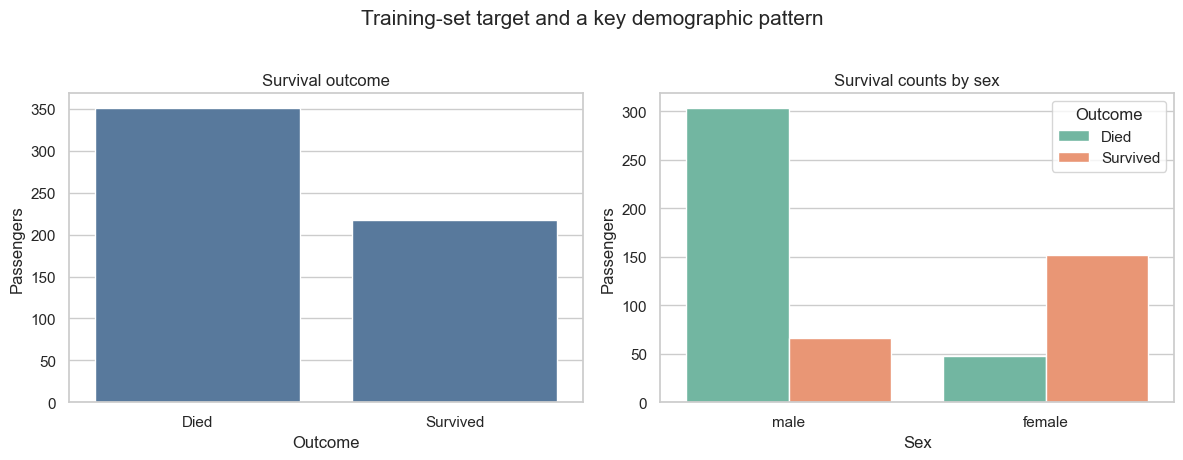

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(data=train_df, x="survived", color="#4C78A8", ax=axes[0])
axes[0].set(title="Survival outcome", xlabel="Outcome", ylabel="Passengers")
axes[0].set_xticks([0, 1], labels=["Died", "Survived"])

sns.countplot(data=train_df, x="sex", hue="survived", palette="Set2", ax=axes[1])
axes[1].set(title="Survival counts by sex", xlabel="Sex", ylabel="Passengers")
handles, _ = axes[1].get_legend_handles_labels()
axes[1].legend(handles, ["Died", "Survived"], title="Outcome")

fig.suptitle("Training-set target and a key demographic pattern", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

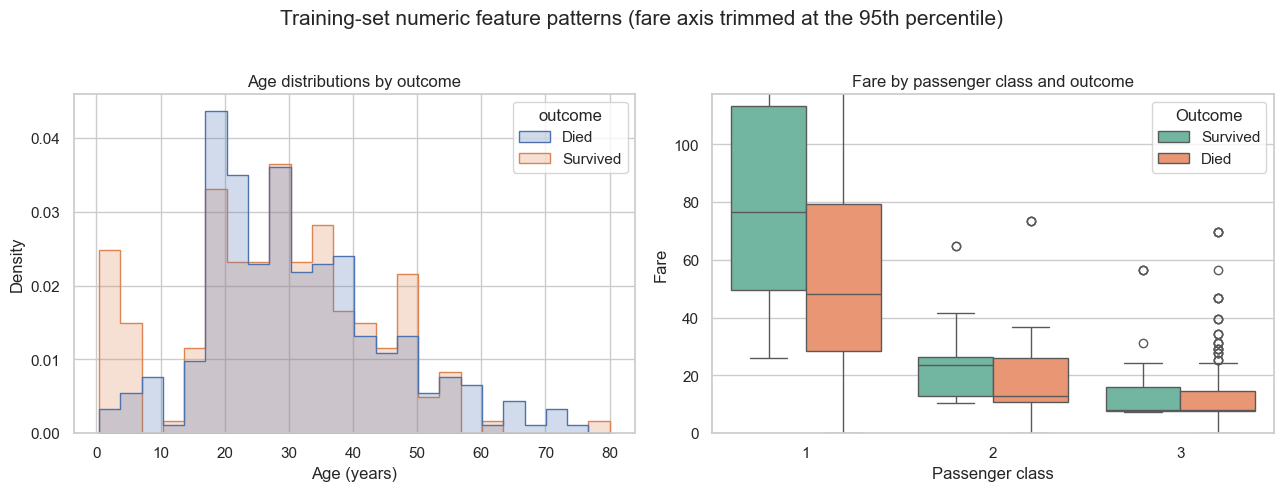

In [5]:
plot_train_df = train_df.assign(outcome=train_df["survived"].map({0: "Died", 1: "Survived"}))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.histplot(
    data=plot_train_df, x="age", hue="outcome", bins=24,
    stat="density", common_norm=False, element="step", ax=axes[0]
)
axes[0].set(title="Age distributions by outcome", xlabel="Age (years)", ylabel="Density")

sns.boxplot(data=plot_train_df, x="pclass", y="fare", hue="outcome", palette="Set2", ax=axes[1])
axes[1].set(title="Fare by passenger class and outcome", xlabel="Passenger class", ylabel="Fare")
axes[1].set_ylim(0, train_df["fare"].quantile(0.95))
axes[1].legend(title="Outcome")

fig.suptitle("Training-set numeric feature patterns (fare axis trimmed at the 95th percentile)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [6]:
survival_rates = (
    train_df.groupby(["pclass", "sex"], observed=True)["survived"]
    .agg(passengers="size", survival_rate="mean")
    .reset_index()
)
survival_rates["survival_rate"] = survival_rates["survival_rate"].round(3)
survival_rates

,pclass,sex,passengers,survival_rate
0,1,female,67,0.970
1,1,male,72,0.389
2,2,female,45,0.933
3,2,male,77,0.182
4,3,female,88,0.511
5,3,male,220,0.109


The training plots show associations, not causes. Passenger class and sex were related to survival in this historical training sample, but the model cannot tell us why and should not be transferred to decisions about people in another setting.

## 4. Build leakage-safe pipelines

`ColumnTransformer` learns imputations, one-hot levels, and scaling statistics only when `.fit()` is called. Numeric measurements are median-imputed and standardized. `pclass`, `sex`, and `embarked` are categorical: they are mode-imputed and one-hot encoded.

Because preprocessing sits inside each model pipeline, cross-validation refits it separately inside every training fold.

In [7]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

models = {
    "Logistic regression": Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1_000, random_state=RANDOM_STATE)),
    ]),
    "Decision tree": Pipeline([
        ("preprocess", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=5, min_samples_leaf=5, random_state=RANDOM_STATE
        )),
    ]),
}

print("Numeric predictors:", numeric_features)
print("Categorical predictors:", categorical_features)

Numeric predictors: ['age', 'sibsp', 'parch', 'fare']
Categorical predictors: ['pclass', 'sex', 'embarked']


## 5. Select a model using training data only

Five-fold stratified cross-validation compares models by the **primary metric, ROC AUC**. Accuracy is shown as a secondary diagnostic. Neither the locked test set nor the interpretation validation set participates in selection.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []

for name, pipeline in models.items():
    scores = cross_validate(
        pipeline,
        X_fit,
        y_fit,
        cv=cv,
        scoring={"roc_auc": PRIMARY_SCORING, "accuracy": "accuracy"},
        n_jobs=1,
    )
    rows.append({
        "model": name,
        "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
        "cv_roc_auc_sd": scores["test_roc_auc"].std(),
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
    })

cv_results = (
    pd.DataFrame(rows)
    .sort_values(["cv_roc_auc_mean", "model"], ascending=[False, True])
    .reset_index(drop=True)
)
cv_results.round(3)

,model,cv_roc_auc_mean,cv_roc_auc_sd,cv_accuracy_mean
0,Logistic regression,0.871,0.047,0.801
1,Decision tree,0.859,0.053,0.817


In [9]:
best_model_name = cv_results.loc[0, "model"]

# The validation partition was reserved before EDA and model selection.
interpretation_model = clone(models[best_model_name]).fit(X_fit, y_fit)

# Validation remains interpretation-only; the locked model uses fit rows only.
best_model = clone(models[best_model_name]).fit(X_fit, y_fit)
baseline = DummyClassifier(strategy="prior").fit(X_fit, y_fit)

print("Selected by mean CV ROC AUC:", best_model_name)
print(f"Selection pool: {len(X_fit)} fit rows; interpretation-only: {len(X_validation)} validation rows")
print("Locked model trained on fit rows only; validation and test remain outside fitting.")

Selected by mean CV ROC AUC: Logistic regression
Selection pool: 569 fit rows; interpretation-only: 143 validation rows
Locked model trained on fit rows only; validation and test remain outside fitting.


## 6. Interpret on a training-derived validation set

Permutation importance uses the held-out **validation subset of the training partition**, never the final test set. Its scorer is the same primary metric used for selection: ROC AUC. Importance is model-specific predictive association, not causality; correlated predictors may share importance.

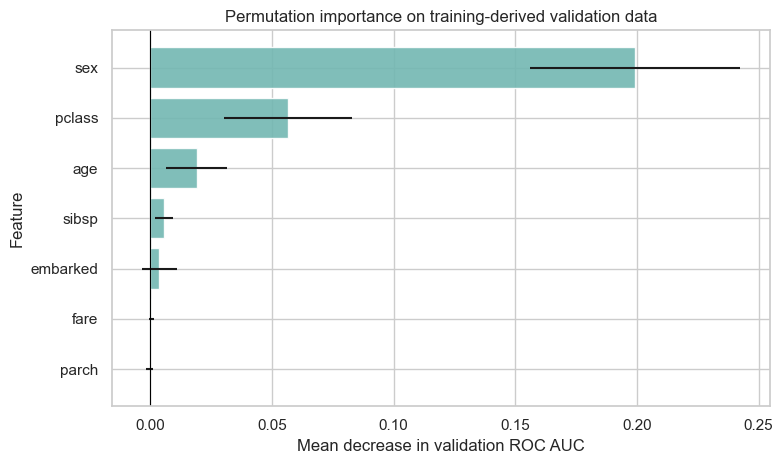

,feature,importance_mean,importance_sd
5,sex,0.199,0.043
4,pclass,0.057,0.026
0,age,0.019,0.013
1,sibsp,0.006,0.004
6,embarked,0.004,0.007
3,fare,0.000,0.001
2,parch,-0.000,0.001


In [10]:
importance_result = permutation_importance(
    interpretation_model,
    X_validation,
    y_validation,
    scoring=PRIMARY_SCORING,
    n_repeats=30,
    random_state=INTERPRETATION_RANDOM_STATE,
    n_jobs=1,
)
importance = (
    pd.DataFrame({
        "feature": feature_columns,
        "importance_mean": importance_result.importances_mean,
        "importance_sd": importance_result.importances_std,
    })
    .sort_values("importance_mean", ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(
    importance["feature"], importance["importance_mean"],
    xerr=importance["importance_sd"], color="#72B7B2", alpha=0.9,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(
    title="Permutation importance on training-derived validation data",
    xlabel="Mean decrease in validation ROC AUC",
    ylabel="Feature",
)
plt.tight_layout()
plt.show()

importance.sort_values("importance_mean", ascending=False).round(3)

## 7. One locked evaluation on the untouched test set

Now—and only now—we access the test partition. ROC AUC is the declared primary metric. A fixed-seed stratified bootstrap gives a descriptive 95% interval for this particular held-out sample; it does not account for dataset shift or model-selection uncertainty.

In [11]:
test_predictions = best_model.predict(X_test)
test_probabilities = best_model.predict_proba(X_test)[:, 1]
baseline_probabilities = baseline.predict_proba(X_test)[:, 1]

test_roc_auc = roc_auc_score(y_test, test_probabilities)
baseline_roc_auc = roc_auc_score(y_test, baseline_probabilities)
test_accuracy = accuracy_score(y_test, test_predictions)

rng = np.random.default_rng(BOOTSTRAP_RANDOM_STATE)
class_indices = [np.flatnonzero(y_test.to_numpy() == label) for label in [0, 1]]
bootstrap_auc = []
for _ in range(2_000):
    sampled = np.concatenate([
        rng.choice(indices, size=len(indices), replace=True) for indices in class_indices
    ])
    bootstrap_auc.append(
        roc_auc_score(y_test.iloc[sampled], test_probabilities[sampled])
    )
auc_ci_low, auc_ci_high = np.percentile(bootstrap_auc, [2.5, 97.5])

print(f"LOCKED TEST {PRIMARY_METRIC}: {test_roc_auc:.3f}")
print(f"Descriptive stratified-bootstrap 95% CI: [{auc_ci_low:.3f}, {auc_ci_high:.3f}]")
print(f"Prior-only baseline ROC AUC: {baseline_roc_auc:.3f}")
print(f"Secondary test accuracy: {test_accuracy:.3f}")
print("\nClassification report (secondary diagnostics):")
print(classification_report(
    y_test, test_predictions, target_names=["Died", "Survived"],
    digits=3, zero_division=0,
))

LOCKED TEST ROC AUC: 0.842
Descriptive stratified-bootstrap 95% CI: [0.774, 0.898]
Prior-only baseline ROC AUC: 0.500
Secondary test accuracy: 0.793

Classification report (secondary diagnostics):
              precision    recall  f1-score   support

        Died      0.802     0.882     0.840       110
    Survived      0.776     0.652     0.709        69

    accuracy                          0.793       179
   macro avg      0.789     0.767     0.774       179
weighted avg      0.792     0.793     0.789       179



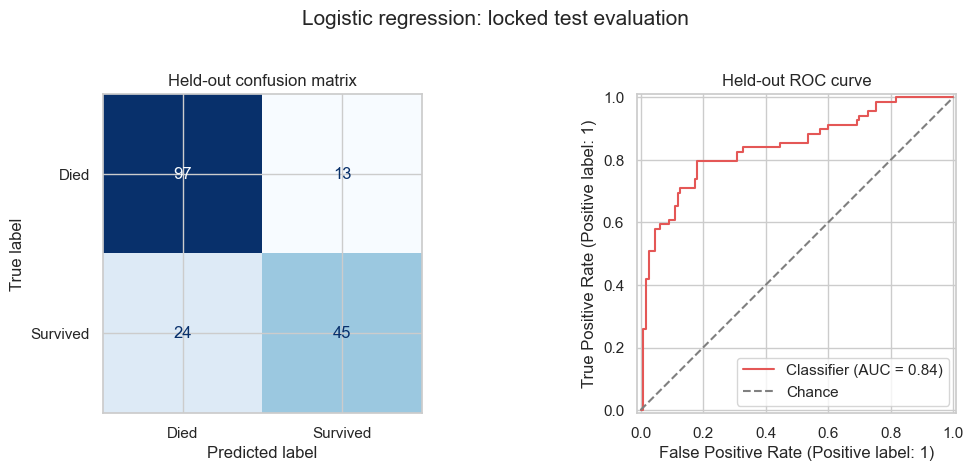

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["Died", "Survived"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Held-out confusion matrix")

RocCurveDisplay.from_predictions(
    y_test, test_probabilities, ax=axes[1], curve_kwargs={"color": "#E45756"}
)
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Chance")
axes[1].set_title("Held-out ROC curve")
axes[1].legend(loc="lower right")

fig.suptitle(f"{best_model_name}: locked test evaluation", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 8. Conclusions and limitations

The locked outputs support a concise project summary:

1. Report test ROC AUC and its descriptive bootstrap interval as the primary result.
2. Compare against the prior-only ROC-AUC baseline and use recall/accuracy only as secondary diagnostics.
3. Interpret permutation importance only on the training-derived validation set and never as causal evidence.
4. Remember that this is one historical passenger list with missing values and social inequities; uncertainty from dataset shift is not represented by the bootstrap interval.

**Possible next steps:** nested cross-validation for hyperparameters, calibration analysis, version-pinned data, and uncertainty across repeated train/test splits.

In [13]:
top_feature = importance.sort_values("importance_mean", ascending=False).iloc[0]["feature"]
print(f"Selected model: {best_model_name}")
print(f"Locked test ROC AUC: {test_roc_auc:.3f} [95% CI {auc_ci_low:.3f}, {auc_ci_high:.3f}]")
print(f"Highest validation ROC-AUC permutation importance: {top_feature}")
print("Titanic capstone complete: validate -> lock test -> train EDA -> CV -> validation interpretation -> locked test.")

Selected model: Logistic regression
Locked test ROC AUC: 0.842 [95% CI 0.774, 0.898]
Highest validation ROC-AUC permutation importance: sex
Titanic capstone complete: validate -> lock test -> train EDA -> CV -> validation interpretation -> locked test.
